In [49]:
import nltk
from pathlib import Path

BASE_DIR = str(Path("..").resolve())
nltk.data.path.append(str(Path(BASE_DIR) / "data" / "nltk_data"))


In [50]:
sessionNames = ['t12.2022.04.28',  't12.2022.05.26',  't12.2022.06.21',  't12.2022.07.21',  't12.2022.08.13',
't12.2022.05.05',  't12.2022.06.02',  't12.2022.06.23',  't12.2022.07.27',  't12.2022.08.18',
't12.2022.05.17',  't12.2022.06.07',  't12.2022.06.28',  't12.2022.07.29',  't12.2022.08.23',
't12.2022.05.19',  't12.2022.06.14',  't12.2022.07.05',  't12.2022.08.02',  't12.2022.08.25',
't12.2022.05.24',  't12.2022.06.16',  't12.2022.07.14',  't12.2022.08.11']
sessionNames.sort()

In [51]:
import re 
from g2p_en import G2p
import numpy as np

g2p = G2p()
PHONE_DEF = [
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH'
]
PHONE_DEF_SIL = PHONE_DEF + ['SIL']

def phoneToId(p):
    return PHONE_DEF_SIL.index(p)

In [52]:
import scipy

def loadFeaturesAndNormalize(sessionPath):
    
    dat = scipy.io.loadmat(sessionPath)

    input_features = []
    transcriptions = []
    frame_lens = []
    block_means = []
    block_stds = []
    n_trials = dat['sentenceText'].shape[0]

    # Collect tx1 AND spikePow features from BOTH brain regions
    # Final layout (512 channels total):
    #   Columns 0-127:   tx1 from Area 6v
    #   Columns 128-255: spikePow from Area 6v
    #   Columns 256-383: tx1 from Area 44
    #   Columns 384-511: spikePow from Area 44
    # 
    # This allows the dual-stream model to split at channel 256:
    #   Stream 6v: channels 0-255 (tx1 + spikePow from ventral premotor)
    #   Stream 44: channels 256-511 (tx1 + spikePow from Broca's area)
    for i in range(n_trials):    
        # Area 6v features (first 128 columns of raw data)
        tx1_6v = dat['tx1'][0,i][:, 0:128]
        spikePow_6v = dat['spikePow'][0,i][:, 0:128]
        
        # Area 44 features (last 128 columns of raw data)
        tx1_44 = dat['tx1'][0,i][:, 128:256]
        spikePow_44 = dat['spikePow'][0,i][:, 128:256]
        
        # Concatenate: [6v_tx1, 6v_spikePow, 44_tx1, 44_spikePow]
        features = np.concatenate([tx1_6v, spikePow_6v, tx1_44, spikePow_44], axis=1)

        sentence_len = features.shape[0]
        sentence = dat['sentenceText'][i].strip()

        input_features.append(features)
        transcriptions.append(sentence)
        frame_lens.append(sentence_len)

    #block-wise feature normalization
    blockNums = np.squeeze(dat['blockIdx'])
    blockList = np.unique(blockNums)
    blocks = []
    for b in range(len(blockList)):
        sentIdx = np.argwhere(blockNums==blockList[b])
        sentIdx = sentIdx[:,0].astype(np.int32)
        blocks.append(sentIdx)

    for b in range(len(blocks)):
        feats = np.concatenate(input_features[blocks[b][0]:(blocks[b][-1]+1)], axis=0)
        feats_mean = np.mean(feats, axis=0, keepdims=True)
        feats_std = np.std(feats, axis=0, keepdims=True)
        for i in blocks[b]:
            input_features[i] = (input_features[i] - feats_mean) / (feats_std + 1e-8)

    #convert to tfRecord file
    session_data = {
        'inputFeatures': input_features,
        'transcriptions': transcriptions,
        'frameLens': frame_lens
    }

    return session_data

In [53]:
import os

def getDataset(fileName):
    session_data = loadFeaturesAndNormalize(fileName)
        
    allDat = []
    trueSentences = []
    seqElements = []
    
    for x in range(len(session_data['inputFeatures'])):
        allDat.append(session_data['inputFeatures'][x])
        trueSentences.append(session_data['transcriptions'][x])
        
        thisTranscription = str(session_data['transcriptions'][x]).strip()
        thisTranscription = re.sub(r'[^a-zA-Z\- \']', '', thisTranscription)
        thisTranscription = thisTranscription.replace('--', '').lower()
        addInterWordSymbol = True

        phonemes = []
        for p in g2p(thisTranscription):
            if addInterWordSymbol and p==' ':
                phonemes.append('SIL')
            p = re.sub(r'[0-9]', '', p)  # Remove stress
            if re.match(r'[A-Z]+', p):  # Only keep phonemes
                phonemes.append(p)

        #add one SIL symbol at the end so there's one at the end of each word
        if addInterWordSymbol:
            phonemes.append('SIL')

        seqLen = len(phonemes)
        maxSeqLen = 500
        seqClassIDs = np.zeros([maxSeqLen]).astype(np.int32)
        seqClassIDs[0:seqLen] = [phoneToId(p) + 1 for p in phonemes]
        seqElements.append(seqClassIDs)

    newDataset = {}
    newDataset['sentenceDat'] = allDat
    newDataset['transcriptions'] = trueSentences
    newDataset['phonemes'] = seqElements
    
    timeSeriesLens = []
    phoneLens = []
    for x in range(len(newDataset['sentenceDat'])):
        timeSeriesLens.append(newDataset['sentenceDat'][x].shape[0])
        
        zeroIdx = np.argwhere(newDataset['phonemes'][x]==0)
        phoneLens.append(zeroIdx[0,0])
    
    newDataset['timeSeriesLens'] = np.array(timeSeriesLens)
    newDataset['phoneLens'] = np.array(phoneLens)
    newDataset['phonePerTime'] = newDataset['phoneLens'].astype(np.float32) / newDataset['timeSeriesLens'].astype(np.float32)
    return newDataset

In [54]:
trainDatasets = []
testDatasets = []
competitionDatasets = []

dataDir = BASE_DIR + '/data/competitionData'

for dayIdx in range(len(sessionNames)):
    print(dayIdx)
    trainDataset = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat')
    testDataset = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat')

    trainDatasets.append(trainDataset)
    testDatasets.append(testDataset)

    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        dataset = getDataset(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat')
        competitionDatasets.append(dataset)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [55]:
dataDir = BASE_DIR + 'data/dual/competitionData'

competitionDays = []
for dayIdx in range(len(sessionNames)):
    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        competitionDays.append(dayIdx)
print(competitionDays)

[]


In [56]:
import pickle
import os

allDatasets = {}
allDatasets['train'] = trainDatasets
allDatasets['test'] = testDatasets
allDatasets['competition'] = competitionDatasets

# Save to dual_region_data directory (512 channels)
output_dir = Path(BASE_DIR) / 'dual_region_data'
os.makedirs(output_dir, exist_ok=True)

with open(output_dir / 'ptDecoder_ctc_dual_region', 'wb') as handle:
    pickle.dump(allDatasets, handle)
    
print("Saved dual-region dataset to dual_region_data/ptDecoder_ctc_dual_region")
print(f"Feature shape: {trainDatasets[0]['sentenceDat'][0].shape}")
print("Channel layout (512 total):")
print("  - Columns 0-127:   tx1 from Area 6v")
print("  - Columns 128-255: spikePow from Area 6v")
print("  - Columns 256-383: tx1 from Area 44")
print("  - Columns 384-511: spikePow from Area 44")
print("\nDual-stream model splits at channel 256:")
print("  - Stream 6v: channels 0-255")
print("  - Stream 44: channels 256-511")

Saved dual-region dataset to dual_region_data/ptDecoder_ctc_dual_region
Feature shape: (478, 512)
Channel layout (512 total):
  - Columns 0-127:   tx1 from Area 6v
  - Columns 128-255: spikePow from Area 6v
  - Columns 256-383: tx1 from Area 44
  - Columns 384-511: spikePow from Area 44

Dual-stream model splits at channel 256:
  - Stream 6v: channels 0-255
  - Stream 44: channels 256-511


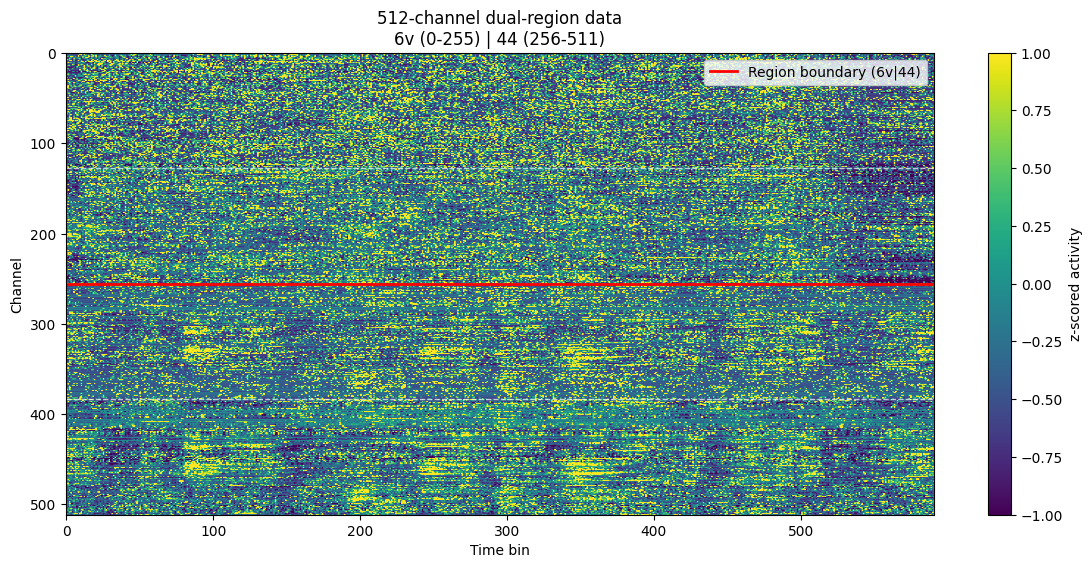

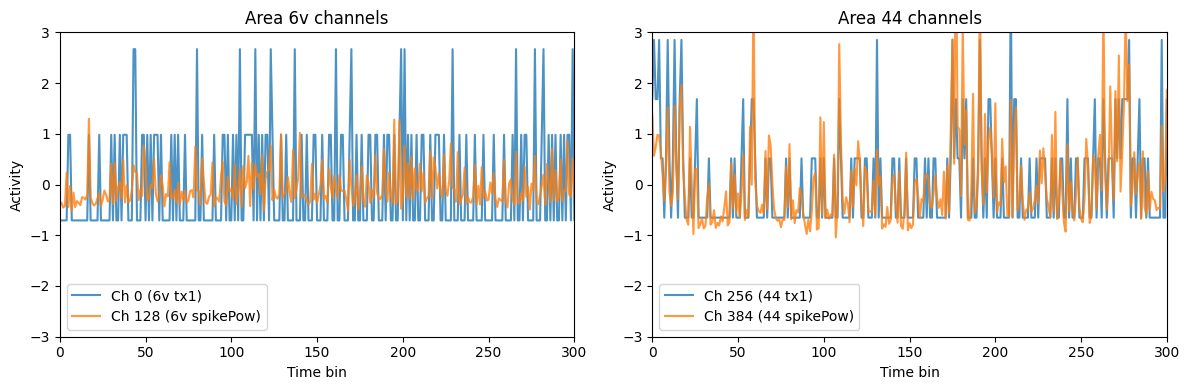

In [57]:
import matplotlib.pyplot as plt

# Visualize all 512 channels
plt.figure(figsize=(14, 6))
plt.imshow(trainDatasets[0]['sentenceDat'][10].T, clim=[-1,1], aspect='auto')
plt.axhline(y=127.5, color='white', linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(y=255.5, color='red', linestyle='-', linewidth=2, label='Region boundary (6v|44)')
plt.axhline(y=383.5, color='white', linestyle='--', linewidth=1, alpha=0.7)
plt.ylabel('Channel')
plt.xlabel('Time bin')
plt.title('512-channel dual-region data\n6v (0-255) | 44 (256-511)')
plt.colorbar(label='z-scored activity')
plt.legend(loc='upper right')
plt.show()

# Compare channels from each region
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(trainDatasets[0]['sentenceDat'][10][:, 0], label='Ch 0 (6v tx1)', alpha=0.8)
plt.plot(trainDatasets[0]['sentenceDat'][10][:, 128], label='Ch 128 (6v spikePow)', alpha=0.8)
plt.xlim([0, 300])
plt.ylim([-3, 3])
plt.xlabel('Time bin')
plt.ylabel('Activity')
plt.title('Area 6v channels')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trainDatasets[0]['sentenceDat'][10][:, 256], label='Ch 256 (44 tx1)', alpha=0.8)
plt.plot(trainDatasets[0]['sentenceDat'][10][:, 384], label='Ch 384 (44 spikePow)', alpha=0.8)
plt.xlim([0, 300])
plt.ylim([-3, 3])
plt.xlabel('Time bin')
plt.ylabel('Activity')
plt.title('Area 44 channels')
plt.legend()

plt.tight_layout()
plt.show()

# Log-Transformed Spike Band Power Version

The Feghhi et al. (2025) Transformer roadmap recommends applying log transform to spike band power features before normalization. This reduces dynamic range and reportedly improves WER by ~4%.

The log transform is applied as: `log(1 + spikePow)` to handle zero values gracefully.


In [58]:
def loadFeaturesAndNormalize_logSBP(sessionPath):
    """
    Load features with LOG TRANSFORM applied to spike band power (spikePow) features.
    
    This follows the Feghhi et al. (2025) recommendation for Transformer training.
    Log transform reduces dynamic range and improves performance by ~4% WER.
    
    Channel layout (512 total):
      Columns 0-127:   tx1 from Area 6v (no transform)
      Columns 128-255: log(1 + spikePow) from Area 6v
      Columns 256-383: tx1 from Area 44 (no transform)
      Columns 384-511: log(1 + spikePow) from Area 44
    """
    dat = scipy.io.loadmat(sessionPath)

    input_features = []
    transcriptions = []
    frame_lens = []
    n_trials = dat['sentenceText'].shape[0]

    for i in range(n_trials):    
        # Area 6v features
        tx1_6v = dat['tx1'][0,i][:, 0:128]
        spikePow_6v = dat['spikePow'][0,i][:, 0:128]
        
        # Area 44 features
        tx1_44 = dat['tx1'][0,i][:, 128:256]
        spikePow_44 = dat['spikePow'][0,i][:, 128:256]
        
        # Apply log transform to spike band power features
        # log(1 + x) to handle zeros gracefully
        spikePow_6v_log = np.log1p(np.maximum(spikePow_6v, 0))  # Ensure non-negative
        spikePow_44_log = np.log1p(np.maximum(spikePow_44, 0))
        
        # Concatenate: [6v_tx1, 6v_spikePow_log, 44_tx1, 44_spikePow_log]
        features = np.concatenate([tx1_6v, spikePow_6v_log, tx1_44, spikePow_44_log], axis=1)

        sentence_len = features.shape[0]
        sentence = dat['sentenceText'][i].strip()

        input_features.append(features)
        transcriptions.append(sentence)
        frame_lens.append(sentence_len)

    # Block-wise feature normalization (same as before)
    blockNums = np.squeeze(dat['blockIdx'])
    blockList = np.unique(blockNums)
    blocks = []
    for b in range(len(blockList)):
        sentIdx = np.argwhere(blockNums==blockList[b])
        sentIdx = sentIdx[:,0].astype(np.int32)
        blocks.append(sentIdx)

    for b in range(len(blocks)):
        feats = np.concatenate(input_features[blocks[b][0]:(blocks[b][-1]+1)], axis=0)
        feats_mean = np.mean(feats, axis=0, keepdims=True)
        feats_std = np.std(feats, axis=0, keepdims=True)
        for i in blocks[b]:
            input_features[i] = (input_features[i] - feats_mean) / (feats_std + 1e-8)

    session_data = {
        'inputFeatures': input_features,
        'transcriptions': transcriptions,
        'frameLens': frame_lens
    }

    return session_data


def getDataset_logSBP(fileName):
    """Get dataset with log-transformed spike band power features."""
    session_data = loadFeaturesAndNormalize_logSBP(fileName)
        
    allDat = []
    trueSentences = []
    seqElements = []
    
    for x in range(len(session_data['inputFeatures'])):
        allDat.append(session_data['inputFeatures'][x])
        trueSentences.append(session_data['transcriptions'][x])
        
        thisTranscription = str(session_data['transcriptions'][x]).strip()
        thisTranscription = re.sub(r'[^a-zA-Z\- \']', '', thisTranscription)
        thisTranscription = thisTranscription.replace('--', '').lower()
        addInterWordSymbol = True

        phonemes = []
        for p in g2p(thisTranscription):
            if addInterWordSymbol and p==' ':
                phonemes.append('SIL')
            p = re.sub(r'[0-9]', '', p)
            if re.match(r'[A-Z]+', p):
                phonemes.append(p)

        if addInterWordSymbol:
            phonemes.append('SIL')

        seqLen = len(phonemes)
        maxSeqLen = 500
        seqClassIDs = np.zeros([maxSeqLen]).astype(np.int32)
        seqClassIDs[0:seqLen] = [phoneToId(p) + 1 for p in phonemes]
        seqElements.append(seqClassIDs)

    newDataset = {}
    newDataset['sentenceDat'] = allDat
    newDataset['transcriptions'] = trueSentences
    newDataset['phonemes'] = seqElements
    
    timeSeriesLens = []
    phoneLens = []
    for x in range(len(newDataset['sentenceDat'])):
        timeSeriesLens.append(newDataset['sentenceDat'][x].shape[0])
        
        zeroIdx = np.argwhere(newDataset['phonemes'][x]==0)
        phoneLens.append(zeroIdx[0,0])
    
    newDataset['timeSeriesLens'] = np.array(timeSeriesLens)
    newDataset['phoneLens'] = np.array(phoneLens)
    newDataset['phonePerTime'] = newDataset['phoneLens'].astype(np.float32) / newDataset['timeSeriesLens'].astype(np.float32)
    return newDataset


In [59]:
# Process all sessions with log-transformed spike band power
print("Processing sessions with log-transformed spike band power...")

trainDatasets_logSBP = []
testDatasets_logSBP = []
competitionDatasets_logSBP = []

dataDir = BASE_DIR + '/data/competitionData'

for dayIdx in range(len(sessionNames)):
    print(f"  Day {dayIdx}: {sessionNames[dayIdx]}")
    trainDataset = getDataset_logSBP(dataDir + '/train/' + sessionNames[dayIdx] + '.mat')
    testDataset = getDataset_logSBP(dataDir + '/test/' + sessionNames[dayIdx] + '.mat')

    trainDatasets_logSBP.append(trainDataset)
    testDatasets_logSBP.append(testDataset)

    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        dataset = getDataset_logSBP(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat')
        competitionDatasets_logSBP.append(dataset)

print("Done!")


Processing sessions with log-transformed spike band power...
  Day 0: t12.2022.04.28
  Day 1: t12.2022.05.05
  Day 2: t12.2022.05.17
  Day 3: t12.2022.05.19
  Day 4: t12.2022.05.24
  Day 5: t12.2022.05.26
  Day 6: t12.2022.06.02
  Day 7: t12.2022.06.07
  Day 8: t12.2022.06.14
  Day 9: t12.2022.06.16
  Day 10: t12.2022.06.21
  Day 11: t12.2022.06.23
  Day 12: t12.2022.06.28
  Day 13: t12.2022.07.05
  Day 14: t12.2022.07.14
  Day 15: t12.2022.07.21
  Day 16: t12.2022.07.27
  Day 17: t12.2022.07.29
  Day 18: t12.2022.08.02
  Day 19: t12.2022.08.11
  Day 20: t12.2022.08.13
  Day 21: t12.2022.08.18
  Day 22: t12.2022.08.23
  Day 23: t12.2022.08.25
Done!


In [60]:
# Save log-transformed dataset
allDatasets_logSBP = {}
allDatasets_logSBP['train'] = trainDatasets_logSBP
allDatasets_logSBP['test'] = testDatasets_logSBP
allDatasets_logSBP['competition'] = competitionDatasets_logSBP

# Save to dual_region_data directory with _logSBP suffix
output_path = output_dir / 'ptDecoder_ctc_dual_region_logSBP'

with open(output_path, 'wb') as handle:
    pickle.dump(allDatasets_logSBP, handle)
    
print(f"Saved log-transformed dataset to: {output_path}")
print(f"Feature shape: {trainDatasets_logSBP[0]['sentenceDat'][0].shape}")
print("\nChannel layout (512 total):")
print("  - Columns 0-127:   tx1 from Area 6v (raw)")
print("  - Columns 128-255: log(1+spikePow) from Area 6v")
print("  - Columns 256-383: tx1 from Area 44 (raw)")
print("  - Columns 384-511: log(1+spikePow) from Area 44")
print("\nTo use this dataset:")
print("  datasetPath: dual_region_data/ptDecoder_ctc_dual_region_logSBP")


Saved log-transformed dataset to: /Users/patrickcarbone/BIOENGR/F25/ECE243A/final_project/neural_seq_decoder/dual_region_data/ptDecoder_ctc_dual_region_logSBP
Feature shape: (478, 512)

Channel layout (512 total):
  - Columns 0-127:   tx1 from Area 6v (raw)
  - Columns 128-255: log(1+spikePow) from Area 6v
  - Columns 256-383: tx1 from Area 44 (raw)
  - Columns 384-511: log(1+spikePow) from Area 44

To use this dataset:
  datasetPath: dual_region_data/ptDecoder_ctc_dual_region_logSBP


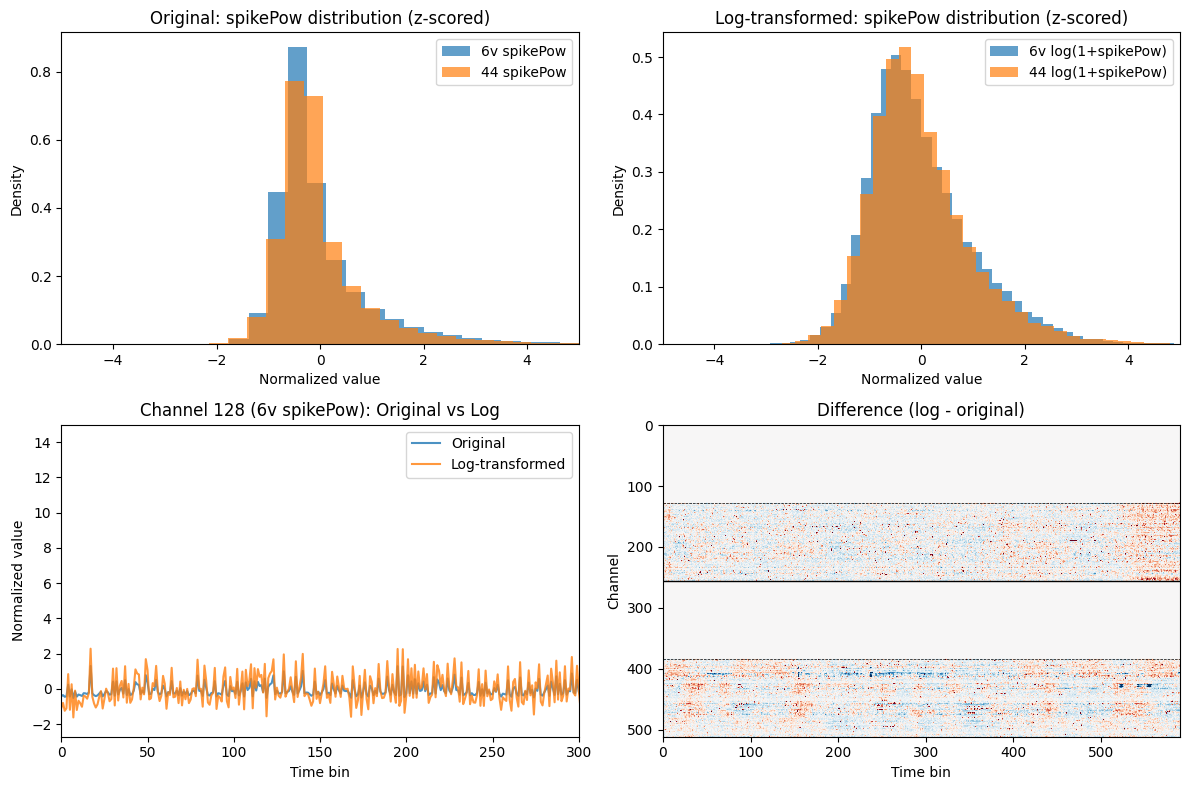


Note: tx1 channels (0-127, 256-383) should be identical.
Only spikePow channels (128-255, 384-511) are transformed.


In [61]:
# Compare original vs log-transformed spike band power distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Get example trial
trial_idx = 10
orig_data = trainDatasets[0]['sentenceDat'][trial_idx]
log_data = trainDatasets_logSBP[0]['sentenceDat'][trial_idx]

# Original spikePow channels (after z-score normalization)
ax = axes[0, 0]
ax.hist(orig_data[:, 128:256].flatten(), bins=50, alpha=0.7, label='6v spikePow', density=True)
ax.hist(orig_data[:, 384:512].flatten(), bins=50, alpha=0.7, label='44 spikePow', density=True)
ax.set_xlabel('Normalized value')
ax.set_ylabel('Density')
ax.set_title('Original: spikePow distribution (z-scored)')
ax.legend()
ax.set_xlim([-5, 5])

# Log-transformed spikePow channels (after z-score normalization)
ax = axes[0, 1]
ax.hist(log_data[:, 128:256].flatten(), bins=50, alpha=0.7, label='6v log(1+spikePow)', density=True)
ax.hist(log_data[:, 384:512].flatten(), bins=50, alpha=0.7, label='44 log(1+spikePow)', density=True)
ax.set_xlabel('Normalized value')
ax.set_ylabel('Density')
ax.set_title('Log-transformed: spikePow distribution (z-scored)')
ax.legend()
ax.set_xlim([-5, 5])

# Time series comparison for one channel
ax = axes[1, 0]
ax.plot(orig_data[:, 128], label='Original', alpha=0.8)
ax.plot(log_data[:, 128], label='Log-transformed', alpha=0.8)
ax.set_xlabel('Time bin')
ax.set_ylabel('Normalized value')
ax.set_title('Channel 128 (6v spikePow): Original vs Log')
ax.legend()
ax.set_xlim([0, 300])

# Heatmap comparison
ax = axes[1, 1]
diff = log_data - orig_data
ax.imshow(diff.T, aspect='auto', cmap='RdBu', clim=[-1, 1])
ax.axhline(y=127.5, color='black', linestyle='--', linewidth=0.5)
ax.axhline(y=255.5, color='black', linestyle='-', linewidth=1)
ax.axhline(y=383.5, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel('Time bin')
ax.set_ylabel('Channel')
ax.set_title('Difference (log - original)')

plt.tight_layout()
plt.show()

print("\nNote: tx1 channels (0-127, 256-383) should be identical.")
print("Only spikePow channels (128-255, 384-511) are transformed.")


In [68]:
from collections import Counter

# Analyze phoneme and diphone distributions in the training set
# Uses logSBP version if available, otherwise falls back to original

if 'trainDatasets_logSBP' in globals():
    train_sets = trainDatasets_logSBP
    print("Using log-transformed training datasets (trainDatasets_logSBP)")
else:
    train_sets = trainDatasets
    print("Using original training datasets (trainDatasets)")

# Map from ID -> phoneme string (ID 0 = padding)
id_to_phone = {i + 1: p for i, p in enumerate(PHONE_DEF_SIL)}

phoneme_counts = Counter()
diphone_counts = Counter()

total_tokens = 0
total_diphones = 0

for day_data in train_sets:
    phoneme_seqs = day_data['phonemes']
    phone_lens = day_data['phoneLens']  # true lengths (before padding)
    for seq, L in zip(phoneme_seqs, phone_lens):
        # Truncate to true length and drop padding (0)
        ids = seq[:int(L)]
        ids = [int(x) for x in ids if x > 0]
        if not ids:
            continue

        # Phoneme counts
        phoneme_counts.update(ids)
        total_tokens += len(ids)

        # Diphone counts (pairs of consecutive phonemes)
        if len(ids) > 1:
            for i in range(len(ids) - 1):
                diphone = (ids[i], ids[i + 1])
                diphone_counts[diphone] += 1
                total_diphones += 1

print(f"\nTotal phoneme tokens (including SIL): {total_tokens}")

# Build phoneme statistics EXCLUDING SIL
non_sil_counts = {
    pid: count
    for pid, count in phoneme_counts.items()
    if id_to_phone.get(pid) != "SIL"
}

print(f"Unique phoneme IDs (excluding SIL): {len(non_sil_counts)}")
if len(non_sil_counts) > 0:
    ph_vals = np.array(list(non_sil_counts.values()), dtype=float)
    avg_ph = ph_vals.mean()
    q1_ph, med_ph, q3_ph = np.percentile(ph_vals, [25, 50, 75])
    std_ph = np.std(ph_vals)
    print(f"Average tokens per phoneme (no SIL): {avg_ph:.2f}")
    print(f"Std dev (tokens, no SIL): {std_ph:.2f}")
    print(f"Min / max tokens per phoneme (no SIL): {ph_vals.min():.0f} / {ph_vals.max():.0f}")
    print(
        f"Phoneme count IQR (no SIL): Q1={q1_ph:.1f}, median={med_ph:.1f}, "
        f"Q3={q3_ph:.1f}, IQR={q3_ph - q1_ph:.1f}"
    )

print(f"Total diphone tokens: {total_diphones}")
print(f"Unique diphones: {len(diphone_counts)}")
if len(diphone_counts) > 0:
    di_vals = np.array(list(diphone_counts.values()), dtype=float)
    avg_di = di_vals.mean()
    q1_di, med_di, q3_di = np.percentile(di_vals, [25, 50, 75])
    std_di = np.std(di_vals)
    print(f"Average tokens per diphone: {avg_di:.2f}")
    print(f"Std dev (tokens): {std_di:.2f}")
    print(f"Min / max tokens per diphone: {di_vals.min():.0f} / {di_vals.max():.0f}")
    print(
        f"Diphone count IQR: Q1={q1_di:.1f}, median={med_di:.1f}, "
        f"Q3={q3_di:.1f}, IQR={q3_di - q1_di:.1f}"
    )

print()

# Convert phoneme counts to sorted list with names (excluding SIL)
phoneme_stats = []
for pid, count in phoneme_counts.items():
    name = id_to_phone.get(pid, f"ID{pid}")
    if name == "SIL":
        continue
    frac = count / total_tokens if total_tokens > 0 else 0.0
    phoneme_stats.append((pid, name, count, frac))

# Most frequent phonemes
phoneme_stats_sorted = sorted(phoneme_stats, key=lambda x: x[2], reverse=True)

print("Top 30 most frequent phonemes (excluding SIL):")
for pid, name, count, frac in phoneme_stats_sorted[:30]:
    print(f"  {name:4s} (id={pid:2d}): {count:7d}  ({frac*100:5.2f}%)")

print("\n10 rarest phonemes (excluding SIL):")
for pid, name, count, frac in sorted(phoneme_stats, key=lambda x: x[2])[:10]:
    print(f"  {name:4s} (id={pid:2d}): {count:7d}  ({frac*100:5.2f}%)")

# Diphone stats (by phoneme names)
def diphone_to_str(d):
    p1 = id_to_phone.get(d[0], f"ID{d[0]}")
    p2 = id_to_phone.get(d[1], f"ID{d[1]}")
    return f"{p1}-{p2}"

print("\nTop 30 most frequent diphones:")
for (p1, p2), count in diphone_counts.most_common(30):
    frac = count / total_diphones if total_diphones > 0 else 0.0
    print(f"  {diphone_to_str((p1, p2)):10s}: {count:7d}  ({frac*100:5.2f}%)")

print("\n10 rarest diphones (among those observed):")
for (p1, p2), count in sorted(diphone_counts.items(), key=lambda x: x[1])[:10]:
    frac = count / total_diphones if total_diphones > 0 else 0.0
    print(f"  {diphone_to_str((p1, p2)):10s}: {count:7d}  ({frac*100:5.2f}%)")


Using log-transformed training datasets (trainDatasets_logSBP)

Total phoneme tokens (including SIL): 247305
Unique phoneme IDs (excluding SIL): 39
Average tokens per phoneme (no SIL): 4914.10
Std dev (tokens, no SIL): 3856.53
Min / max tokens per phoneme (no SIL): 678 / 17366
Phoneme count IQR (no SIL): Q1=2253.5, median=3912.0, Q3=5948.5, IQR=3695.0
Total diphone tokens: 238505
Unique diphones: 974
Average tokens per diphone: 244.87
Std dev (tokens): 604.12
Min / max tokens per diphone: 1 / 7788
Diphone count IQR: Q1=8.0, median=49.0, Q3=198.8, IQR=190.8

Top 30 most frequent phonemes (excluding SIL):
  AH   (id= 3):   17366  ( 7.02%)
  T    (id=31):   15456  ( 6.25%)
  N    (id=23):   12060  ( 4.88%)
  IH   (id=17):   11691  ( 4.73%)
  S    (id=29):    8903  ( 3.60%)
  R    (id=28):    8049  ( 3.25%)
  D    (id= 9):    7850  ( 3.17%)
  L    (id=21):    7626  ( 3.08%)
  IY   (id=18):    7049  ( 2.85%)
  K    (id=20):    6037  ( 2.44%)
  DH   (id=10):    5860  ( 2.37%)
  EH   (id=11):

In [72]:
from collections import defaultdict

# Create a RESAMPLED training set where:
#   - Every phoneme occurs at least min_phoneme_count times
#   - Every OBSERVED diphone occurs at least min_diphone_count times
# We operate on the logSBP dual-region dataset, since that's what we train with.

min_phoneme_count = 1000
min_diphone_count = 6
max_duplicates_per_trial = 1  # Hard cap: no trial may be duplicated 10+ times

if 'trainDatasets_logSBP' not in globals():
    raise RuntimeError("Expected trainDatasets_logSBP to exist. Run the logSBP cells first.")

source_train = trainDatasets_logSBP

# 1) Recompute global phoneme & diphone counts from source_train
phoneme_counts_res = Counter()
diphone_counts_res = Counter()

trial_infos = []  # store per-trial stats for resampling

for day_idx, day_data in enumerate(source_train):
    phoneme_seqs = day_data['phonemes']
    phone_lens = day_data['phoneLens']
    for trial_idx, (seq, L) in enumerate(zip(phoneme_seqs, phone_lens)):
        ids = seq[:int(L)]
        ids = [int(x) for x in ids if x > 0]
        if not ids:
            continue

        # Per-trial counts
        ph_counter = Counter(ids)
        di_counter = Counter()
        if len(ids) > 1:
            for i in range(len(ids) - 1):
                di = (ids[i], ids[i + 1])
                di_counter[di] += 1

        # Update global counts
        phoneme_counts_res.update(ph_counter)
        diphone_counts_res.update(di_counter)

        trial_infos.append(
            {
                'day': day_idx,
                'idx': trial_idx,
                'phones': ph_counter,
                'diphones': di_counter,
            }
        )

print("Initial counts for logSBP training set:")
print(f"  Total phoneme tokens: {sum(phoneme_counts_res.values())}")
print(f"  Unique phonemes: {len(phoneme_counts_res)}")
print(f"  Total diphone tokens: {sum(diphone_counts_res.values())}")
print(f"  Unique diphones: {len(diphone_counts_res)}")

rare_phones = {p: c for p, c in phoneme_counts_res.items() if c < min_phoneme_count}
rare_diphones = {d: c for d, c in diphone_counts_res.items() if c < min_diphone_count}

print(f"  Phonemes below {min_phoneme_count}: {len(rare_phones)}")
print(f"  Diphones below {min_diphone_count}: {len(rare_diphones)}")

# 2) Greedy resampling: duplicate whole trials that contain rare items

def recompute_rare():
    rare_p = {p: min_phoneme_count - c for p, c in phoneme_counts_res.items() if c < min_phoneme_count}
    rare_d = {d: min_diphone_count - c for d, c in diphone_counts_res.items() if c < min_diphone_count}
    return rare_p, rare_d

duplicates_per_trial = defaultdict(int)
max_iters = 50000

for it in range(max_iters):
    rare_p, rare_d = recompute_rare()
    if not rare_p and not rare_d:
        print(f"All thresholds satisfied after {it} duplication steps.")
        break

    # Score each trial by how many remaining rare tokens it can contribute
    best_trial = None
    best_score = 0

    for info in trial_infos:
        d = info['day']
        t = info['idx']

        # Skip trials that already hit the duplicate cap
        if duplicates_per_trial[(d, t)] >= max_duplicates_per_trial:
            continue

        score = 0
        # Phonemes
        for pid, cnt in info['phones'].items():
            if pid in rare_p:
                score += min(cnt, rare_p[pid])
        # Diphones
        for dp, cnt in info['diphones'].items():
            if dp in rare_d:
                score += min(cnt, rare_d[dp])

        if score > best_score:
            best_score = score
            best_trial = info

    if best_trial is None or best_score == 0:
        print("No trial can further reduce deficits; stopping early.")
        break

    # Duplicate the best trial once
    d = best_trial['day']
    t = best_trial['idx']
    duplicates_per_trial[(d, t)] += 1

    # Update global counts
    phoneme_counts_res.update(best_trial['phones'])
    diphone_counts_res.update(best_trial['diphones'])

else:
    print(f"Reached max_iters={max_iters} before fully satisfying thresholds.")

# Final stats
rare_p_final, rare_d_final = recompute_rare()
print("\nFinal counts after resampling suggestions:")
print(f"  Phonemes still below {min_phoneme_count}: {len(rare_p_final)}")
print(f"  Diphones still below {min_diphone_count}: {len(rare_d_final)}")
if rare_p_final:
    print("  Example remaining rare phonemes:")
    for pid, deficit in list(rare_p_final.items())[:10]:
        name = id_to_phone.get(pid, f"ID{pid}")
        print(f"    {name} (id={pid}): deficit {deficit}")
if rare_d_final:
    print("  Example remaining rare diphones:")
    for dp, deficit in list(rare_d_final.items())[:10]:
        print(f"    {diphone_to_str(dp)}: deficit {deficit}")

print(f"\nNon-zero duplication counts: {sum(d > 0 for d in duplicates_per_trial.values())}")
if duplicates_per_trial:
    print(f"Max duplicates for any single trial: {max(duplicates_per_trial.values())}")

# 3) Build balanced training datasets by actually duplicating trials
balanced_train_logSBP = []

for day_idx, day_data in enumerate(source_train):
    sent = day_data['sentenceDat']
    trans = day_data['transcriptions']
    phones = day_data['phonemes']
    t_lens = day_data['timeSeriesLens']
    p_lens = day_data['phoneLens']
    ppt = day_data['phonePerTime']

    new_sent = []
    new_trans = []
    new_phones = []
    new_t_lens = []
    new_p_lens = []
    new_ppt = []

    for trial_idx in range(len(sent)):
        k = duplicates_per_trial[(day_idx, trial_idx)]
        # Original trial
        new_sent.append(sent[trial_idx])
        new_trans.append(trans[trial_idx])
        new_phones.append(phones[trial_idx])
        new_t_lens.append(t_lens[trial_idx])
        new_p_lens.append(p_lens[trial_idx])
        new_ppt.append(ppt[trial_idx])

        # Duplicates
        for _ in range(k):
            new_sent.append(sent[trial_idx])
            new_trans.append(trans[trial_idx])
            new_phones.append(phones[trial_idx])
            new_t_lens.append(t_lens[trial_idx])
            new_p_lens.append(p_lens[trial_idx])
            new_ppt.append(ppt[trial_idx])

    balanced_day = {
        'sentenceDat': new_sent,
        'transcriptions': new_trans,
        'phonemes': new_phones,
        'timeSeriesLens': np.array(new_t_lens),
        'phoneLens': np.array(new_p_lens),
        'phonePerTime': np.array(new_ppt, dtype=np.float32),
    }
    balanced_train_logSBP.append(balanced_day)

orig_trials = sum(len(d['sentenceDat']) for d in source_train)
new_trials = sum(len(d['sentenceDat']) for d in balanced_train_logSBP)
print(f"\nOriginal #train trials: {orig_trials}")
print(f"Balanced  #train trials: {new_trials}")

# 4) Save new balanced dataset alongside others
balanced_datasets_logSBP = {
    'train': balanced_train_logSBP,
    'test': testDatasets_logSBP,
    'competition': competitionDatasets_logSBP,
}

balanced_path = output_dir / 'ptDecoder_ctc_dual_region_logSBP_balanced'
with open(balanced_path, 'wb') as handle:
    pickle.dump(balanced_datasets_logSBP, handle)

print(f"\nSaved balanced logSBP dataset to: {balanced_path}")
print("To use this dataset in configs, set:")
print("  datasetPath: dual_region_data/ptDecoder_ctc_dual_region_logSBP_balanced")



Initial counts for logSBP training set:
  Total phoneme tokens: 247305
  Unique phonemes: 40
  Total diphone tokens: 238505
  Unique diphones: 974
  Phonemes below 1000: 3
  Diphones below 6: 198
No trial can further reduce deficits; stopping early.

Final counts after resampling suggestions:
  Phonemes still below 1000: 0
  Diphones still below 6: 106
  Example remaining rare diphones:
    T-K: deficit 4
    NG-TH: deficit 2
    P-B: deficit 2
    OW-AO: deficit 2
    G-S: deficit 4
    M-SH: deficit 4
    T-CH: deficit 4
    B-W: deficit 2
    D-OY: deficit 4
    F-N: deficit 4

Non-zero duplication counts: 630
Max duplicates for any single trial: 1

Original #train trials: 8800
Balanced  #train trials: 9430

Saved balanced logSBP dataset to: /Users/patrickcarbone/BIOENGR/F25/ECE243A/final_project/neural_seq_decoder/dual_region_data/ptDecoder_ctc_dual_region_logSBP_balanced
To use this dataset in configs, set:
  datasetPath: dual_region_data/ptDecoder_ctc_dual_region_logSBP_balanced
